# Day 4 — t-SNE & Anomaly Detection

In this day, we will use t-SNE to visualize high-dimensional data
and Isolation Forest to detect anomalous observations.

The main objectives are:
- Visualize high-dimensional data using t-SNE.
- Compare t-SNE with PCA.
- Understand anomaly detection.
- Detect anomalies using Isolation Forest.
- Inspect and interpret flagged observations.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest



In [6]:
df=pd.read_csv("heart.csv")

## Step 3 — Prepare the Data

We select numerical health-related features for dimensionality reduction
and anomaly detection.

The selected features are:
- Age
- RestingBP
- Cholesterol
- FastingBS
- MaxHR
- Oldpeak

In [7]:
clustering_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "MaxHR",
    "Oldpeak",
]

X_cluster = df[clustering_features]

## Step 4 — Feature Scaling

The selected features have different ranges and units.

For example, Age, Cholesterol, and MaxHR have different scales.
Therefore, StandardScaler is used to standardize the features before
applying t-SNE and Isolation Forest.

Standardization ensures that features with larger numerical ranges
do not dominate the analysis.

In [8]:

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

## Step 5 — K-Means Clustering Labels

K-Means is used to create cluster labels that will later be used
to color the t-SNE visualization.

We selected 3 clusters to visualize possible groups of patients
in the dataset.

In [9]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

## Step 5 — t-SNE Dimensionality Reduction

t-SNE is a dimensionality-reduction technique mainly designed for
visualization.

Unlike PCA, which focuses on preserving global variance, t-SNE
focuses on preserving local neighborhoods.

We reduce the six-dimensional dataset to two dimensions so that
the observations can be visualized in a 2D plot.

In [10]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

## Step 6 — PCA vs t-SNE

PCA and t-SNE are both dimensionality-reduction techniques, but they
serve different purposes.

PCA focuses on preserving global variance and provides meaningful
directions through its principal components.

t-SNE focuses on preserving local neighborhoods and is mainly used
for visualization.

Therefore:

- PCA is faster and can be useful for dimensionality reduction
  before modeling.
- t-SNE is mainly useful for exploring and visualizing complex
  high-dimensional datasets.
- PCA components have interpretable variance information.
- t-SNE axes do not have a direct meaningful interpretation.

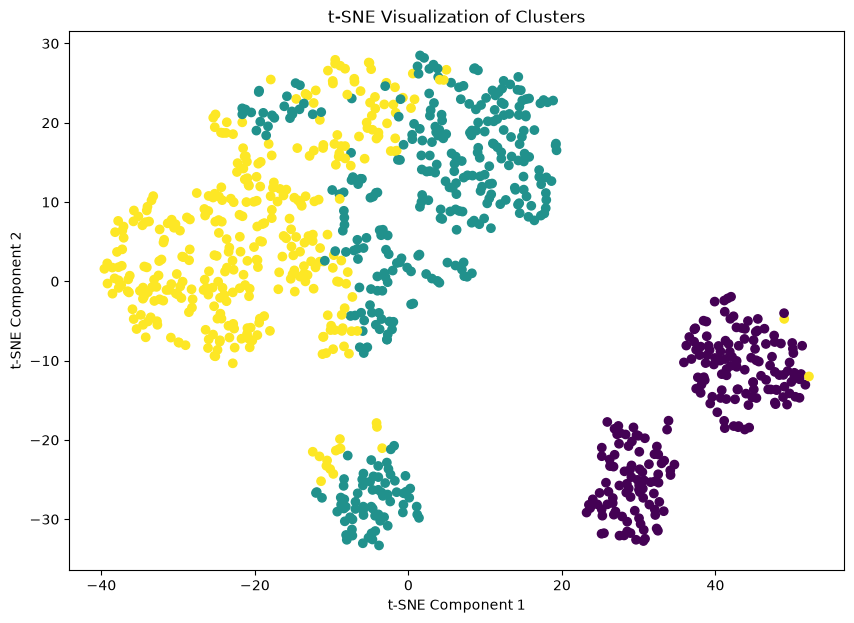

In [11]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=kmeans_labels
)

plt.title("t-SNE Visualization of Clusters")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

plt.show()

### Interpretation

The t-SNE visualization shows the observations in a two-dimensional
space, with colors representing the K-Means cluster assignments.

t-SNE is useful for visually identifying local groups and possible
cluster separation.

However, the t-SNE axes do not have a direct physical meaning.
The plot should therefore be used for visualization rather than
as input for a machine learning model.

## Step 7 — Isolation Forest

Isolation Forest is an unsupervised anomaly-detection algorithm.

It works by randomly partitioning the data and measuring how easily
each observation can be isolated.

Observations that are isolated quickly are considered more likely
to be anomalies.

The contamination parameter represents the expected proportion of
anomalies in the dataset.

Here, contamination=0.05 means that we expect approximately 5% of
the observations to be anomalies.

In [12]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

anomaly_labels = iso.fit_predict(X_scaled)

## Step 8 — Number of Detected Anomalies

Isolation Forest assigns:

- `1` → Normal observation
- `-1` → Anomaly

We count the observations labeled as `-1` to determine how many
anomalies were detected.

In [13]:
n_anomalies = (anomaly_labels == -1).sum()

print("Number of anomalies:", n_anomalies)

Number of anomalies: 46


## Step 9 — Add Anomaly Labels

The Isolation Forest predictions are added to the original DataFrame
so that we can inspect the characteristics of the detected anomalies.

In [14]:
df["Anomaly"] = anomaly_labels

## Step 10 — Inspect Detected Anomalies

We filter the dataset to keep only observations classified as
anomalies.

These observations will be inspected to understand which feature
values may have caused them to differ from the majority of the data.

In [17]:
anomalies = df[df["Anomaly"] == -1]

anomalies.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,Anomaly
68,52,M,ASY,160,246,0,ST,82,Y,4.0,Flat,1,-1
76,32,M,ASY,118,529,0,Normal,130,N,0.0,Flat,1,-1
103,40,M,ASY,120,466,1,Normal,152,Y,1.0,Flat,1,-1
149,54,M,ASY,130,603,1,Normal,125,Y,1.0,Flat,1,-1
155,56,M,ASY,155,342,1,Normal,150,Y,3.0,Flat,1,-1


In [19]:
two_anomalies = anomalies[clustering_features].head(2)

two_anomalies

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak
68,52,160,246,0,82,4.0
76,32,118,529,0,130,0.0


## Step 12 — Inspect Anomaly Scores

Isolation Forest also provides an anomaly score using the
decision_function.

Lower scores indicate observations that are more likely to be
anomalous.

We inspect the first two flagged observations together with their
feature values and anomaly scores.

In [20]:
anomaly_scores = iso.decision_function(X_scaled)

df["Anomaly_Score"] = anomaly_scores

df[df["Anomaly"] == -1][
    clustering_features + ["Anomaly_Score"]
].head(2)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Anomaly_Score
68,52,160,246,0,82,4.0,-0.036936
76,32,118,529,0,130,0.0,-0.011151


## Step 14 — Visualizing Anomalies

The t-SNE visualization is used to visualize the observations
classified as normal and anomalous.

Anomalies may appear away from dense groups of observations.
However, t-SNE should only be used as a visual aid because it can
distort global distances and relationships.

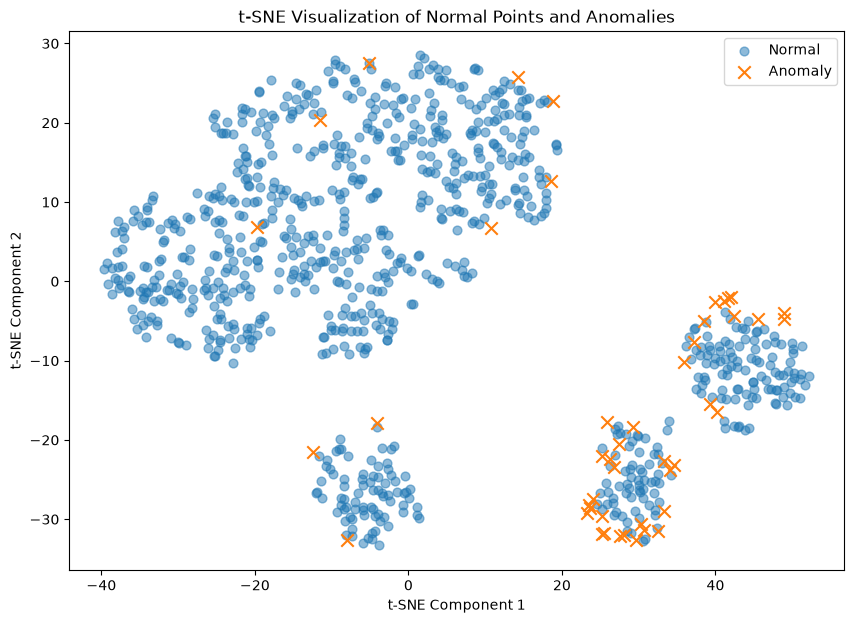

In [23]:
plt.figure(figsize=(10, 7))

normal = anomaly_labels == 1
anomaly = anomaly_labels == -1

plt.scatter(
    X_tsne[normal, 0],
    X_tsne[normal, 1],
    s=40,
    alpha=0.5,
    label="Normal"
)

plt.scatter(
    X_tsne[anomaly, 0],
    X_tsne[anomaly, 1],
    s=80,
    marker="x",
    label="Anomaly"
)

plt.title("t-SNE Visualization of Normal Points and Anomalies")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()
plt.show()